# SWE-ContextBench Repository Density Analysis
Since the dataset natively only provides relationships of length 2, we must build our own 10-task dependency chains using chronological diff overlaps. 
To do this, we need to find the densest repositories in the dataset to maximize our chances of finding a valid 10-task continuous chain.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# 1. Load Base Tasks Dataset
print("Loading SWE-ContextBench base tasks...")
url_base = "https://huggingface.co/datasets/jiayuanz3/SWEContextBench/resolve/main/data/SWEContextBench_Related.parquet"
base_df = pd.read_parquet(url_base)
print(f"Loaded {len(base_df)} total base tasks.")

Loading SWE-ContextBench base tasks...
Loaded 376 total base tasks.


In [3]:
# 2. Calculate Density per Repository
repo_counts = base_df['repo'].value_counts()

print("--- Top 15 Densest Repositories ---")
print(repo_counts.head(15))

--- Top 15 Densest Repositories ---
repo
django/django                93
sympy/sympy                  57
matplotlib/matplotlib        27
sphinx-doc/sphinx            23
scikit-learn/scikit-learn    16
pydata/xarray                12
astropy/astropy              11
jqlang/jq                    11
psf/requests                  9
sharkdp/bat                   9
pytest-dev/pytest             8
axios/axios                   6
gin-gonic/gin                 6
redis/redis                   6
pylint-dev/pylint             5
Name: count, dtype: int64


/var/folders/st/3tywxpjx1ll7mtjfvh3hjpch0000gn/T/ipykernel_88998/1643244206.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_repos.values, y=top_repos.index, palette="viridis")


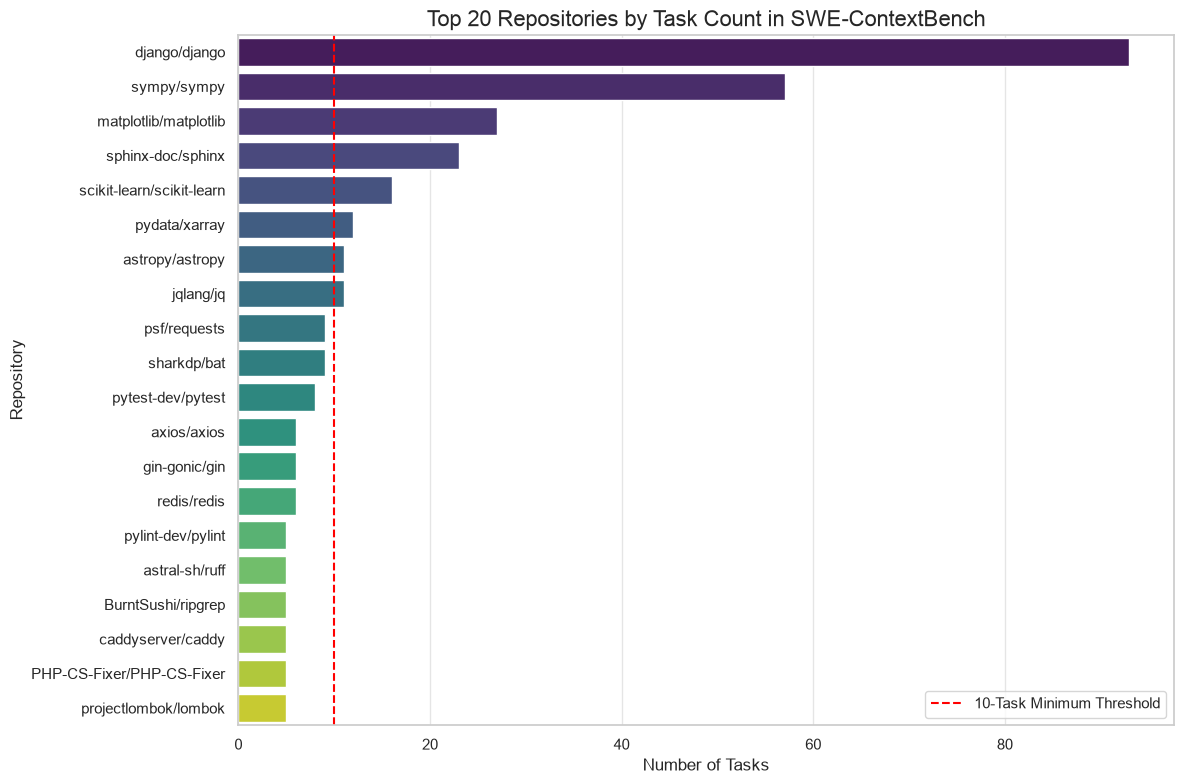

In [4]:
# 3. Plotting the Distribution
top_n = 20
top_repos = repo_counts.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_repos.values, y=top_repos.index, palette="viridis")
plt.title(f'Top {top_n} Repositories by Task Count in SWE-ContextBench', fontsize=16)
plt.xlabel('Number of Tasks', fontsize=12)
plt.ylabel('Repository', fontsize=12)

# Add a vertical line to indicate our 10-task minimum threshold
plt.axvline(x=10, color='red', linestyle='--', label='10-Task Minimum Threshold')
plt.legend()
plt.tight_layout()
plt.show()